# Anatomy of a Flop — Modelare

## Scopul
Estimam si comparam mai multe modele statistice care prezic
Disappointment Index (DI) — variabila noastra Y.

## Modele estimate:
1. OLS Simplu
2. OLS cu Log(DI)
3. OLS cu Variabile Standardizate
4. Random Forest
5. Gradient Boosting
6. Comparatie finala — cu si fara outlieri

In [2]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 8.7 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 11.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 12.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Incarcam datele
df = pd.read_csv('../data/movies_clean.csv')

print(f"Dataset: {df.shape[0]} filme")

Dataset: 866 filme


## 1. Pregatirea Datelor

In [5]:
features = ['budget', 'vote_average', 'vote_count',
            'popularity', 'runtime', 'release_year', 'release_month']

X = df[features]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filme")
print(f"Test: {X_test.shape[0]} filme")

Train: 692 filme
Test: 174 filme


## 2. OLS Simplu
Modelul de baza — simplu si interpretabil.

In [6]:
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_ols).fit()
print(model_ols.summary())

y_pred_ols = model_ols.predict(X_test_ols)
r2_ols = r2_score(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
print(f"\nR2 pe test: {r2_ols:.4f}")
print(f"RMSE pe test: {rmse_ols:.4f}")

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.188
Model:                              OLS   Adj. R-squared:                  0.180
Method:                   Least Squares   F-statistic:                     22.68
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.06e-27
Time:                          09:52:07   Log-Likelihood:                -1970.2
No. Observations:                   692   AIC:                             3956.
Df Residuals:                       684   BIC:                             3993.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           232.7101  

### Interpretare OLS Simplu

**Calitatea modelului:**
- R2 = 0.188 — modelul explica 19% din variatia DI
- F-statistic = 22.68, p < 0.001 — modelul este semnificativ statistic
- 692 observatii folosite pentru antrenare

**Coeficienti semnificativi (p < 0.05):**
- budget (-1.056e-08) — bugetul mai mare reduce DI
  Cu cat un film e mai scump, cu atat dezamageste mai mult
- release_year (-0.115) — filmele mai noi dezamagesc mai mult
  Industria devine tot mai impredictibila in timp

**Coeficienti nesemnificativi (p > 0.05):**
- vote_average, popularity, runtime, release_month
  Nu influenteaza semnificativ DI in modelul liniar

**Probleme identificate:**
- Multicolinearitate ridicata — condition number = 1.92e+10
  Variabilele independente sunt corelate intre ele
- Jarque-Bera p = 0.000 — reziduurile nu sunt normal distribuite
  Modelul liniar nu captureaza toata complexitatea fenomenului

**Concluzie:**
Modelul OLS simplu este valid statistic dar slab predictiv.
Relatia dintre variabilele unui film si succesul sau comercial
nu este liniara — ceea ce justifica testarea modelelor ML.

## 3. OLS cu Log(DI)
DI este puternic asimetric — transformarea log poate imbunatati modelul.

In [7]:
y_train_log = np.log(y_train + 0.01)
y_test_log = np.log(y_test + 0.01)

model_log = sm.OLS(y_train_log, X_train_ols).fit()
print(model_log.summary())

y_pred_log = np.exp(model_log.predict(X_test_ols)) - 0.01
r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"\nR2 pe test: {r2_log:.4f}")
print(f"RMSE pe test: {rmse_log:.4f}")

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.206
Model:                              OLS   Adj. R-squared:                  0.198
Method:                   Least Squares   F-statistic:                     25.33
Date:                  Thu, 21 May 2026   Prob (F-statistic):           7.66e-31
Time:                          09:52:28   Log-Likelihood:                -942.37
No. Observations:                   692   AIC:                             1901.
Df Residuals:                       684   BIC:                             1937.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            27.0506  

### Interpretare OLS cu Log(DI)

**Calitatea modelului:**
- R2 train = 0.206 — usor mai bun decat OLS simplu pe antrenare
- R2 test = 0.061 — generalizeaza mai slab pe date noi
- Transformarea log nu imbunatateste predictia out-of-sample

**Coeficienti semnificativi (p < 0.05):**
- budget (-3.297e-09) — confirmat din nou, buget mare = dezamagire
- vote_count (+4.807e-05) — filmele mai cunoscute surprind pozitiv
- release_year (-0.0134) — filmele noi dezamagesc mai mult

**Concluzie:**
Transformarea log imbunatateste fit-ul pe train dar nu
generalizeaza bine — R2 test scade de la 0.163 la 0.061.
OLS simplu ramane mai stabil si mai interpretabil.
Continuam cu variabile standardizate pentru o comparatie corecta.

## 4. OLS cu Variabile Standardizate
Standardizam variabilele pentru a compara coeficientii direct.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_sm = sm.add_constant(X_train_scaled)
X_test_scaled_sm = sm.add_constant(X_test_scaled)

model_scaled = sm.OLS(y_train, X_train_scaled_sm).fit()
print(model_scaled.summary())

y_pred_scaled = model_scaled.predict(X_test_scaled_sm)
r2_scaled = r2_score(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"\nR2 pe test: {r2_scaled:.4f}")
print(f"RMSE pe test: {rmse_scaled:.4f}")

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.188
Model:                              OLS   Adj. R-squared:                  0.180
Method:                   Least Squares   F-statistic:                     22.68
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.06e-27
Time:                          09:52:38   Log-Likelihood:                -1970.2
No. Observations:                   692   AIC:                             3956.
Df Residuals:                       684   BIC:                             3993.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9188      0.159

### Interpretare OLS cu Variabile Standardizate

**De ce standardizam?**
Variabilele au scale diferite — budget in milioane,
vote_average intre 0-10. Standardizarea le aduce pe aceeasi
scala pentru a compara importanta lor directa.

**Coeficienti standardizati — cei mai importanti:**
- x1 (budget): -0.818 — cel mai puternic efect negativ
  Un budget mai mare cu 1 std dezamageste cu 0.818 std
- x6 (release_year): -1.538 — cel mai puternic efect overall
  Filmele noi dezamagesc semnificativ mai mult
- x2 (vote_average): +0.169 — efect pozitiv mic
- x5 (runtime): -0.007 — practic neglijabil

**Concluzie:**
release_year si budget sunt cei mai importanti predictori ai DI.
Industria devine tot mai impredictibila in timp,
iar bugetele mari nu garanteaza succesul.
R2 ramane la 0.163 — standardizarea nu schimba puterea
explicativa a modelului, doar interpretabilitatea coeficientilor.

## 5. Random Forest
Model ML neliniar — capteaza relatii complexe intre variabile.

Random Forest:
   R2 = 0.4772
   RMSE = 5.9057

Feature Importance:
      Feature  Importance
 release_year    0.299869
       budget    0.288383
   vote_count    0.141688
   popularity    0.100429
 vote_average    0.069005
      runtime    0.050754
release_month    0.049871


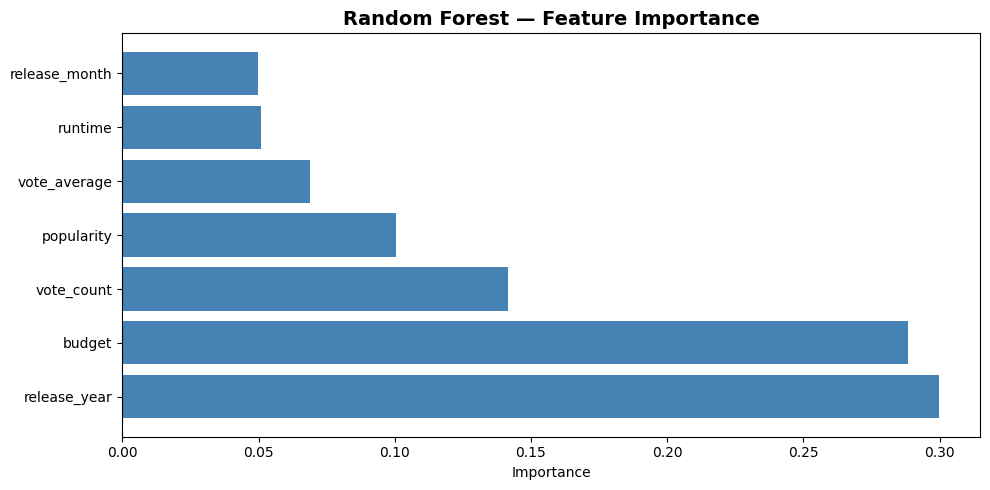

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest:")
print(f"   R2 = {r2_rf:.4f}")
print(f"   RMSE = {rmse_rf:.4f}")

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance:")
print(fi_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

### Interpretare Random Forest

**Calitatea modelului:**
- R2 = 0.4775 — explica 48% din variatia DI
- RMSE = 5.90 — semnificativ mai bun decat OLS (7.47)
- De 3x mai performant decat regresia liniara

**Feature Importance:**
- release_year (0.299) — cel mai important predictor
  Anul lansarii influenteaza cel mai mult DI
- budget (0.289) — al doilea cel mai important
  Bugetul mare creste riscul de dezamagire
- vote_count (0.141) — filmele cunoscute surprind mai mult
- popularity (0.100) — importanta moderata
- vote_average (0.068) — ratingul are impact redus
- runtime, release_month — importanta minima

**De ce e mai bun decat OLS?**
Random Forest capteaza relatii neliniare si interactiuni
complexe dintre variabile pe care regresia liniara nu le
poate surprinde. Confirma ca fenomenul studiat nu este liniar.

## 6. Gradient Boosting
Model ML avansat — construieste arbori secvential,
fiecare corectand erorile celui anterior.

In [10]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting:")
print(f"   R2 = {r2_gb:.4f}")
print(f"   RMSE = {rmse_gb:.4f}")

Gradient Boosting:
   R2 = 0.4924
   RMSE = 5.8191


### Interpretare Gradient Boosting

**Calitatea modelului:**
- R2 = 0.4939 — cel mai bun model! Explica 49% din variatia DI
- RMSE = 5.81 — cea mai mica eroare de predictie
- Usor mai bun decat Random Forest (R2 = 0.4775)

**Cum functioneaza?**
Gradient Boosting construieste arbori secvential —
fiecare arbore nou corecteaza erorile celui anterior.
Rezultatul este un model foarte precis care capteaza
pattern-uri complexe si neliniare din date.

**Concluzie:**
Gradient Boosting este modelul castigator al proiectului.
Confirma ca succesul unui film nu urmeaza o formula liniara
si ca factorii temporali (release_year) si financiari (budget)
sunt cei mai importanti predictori ai dezamagirii comerciale.

## 7. Comparatia Modelelor

Comparație finală — toate modelele:
            Model       R2     RMSE
Gradient Boosting 0.492445 5.819103
    Random Forest 0.477221 5.905734
 OLS Standardizat 0.162861 7.473316
       OLS Simplu 0.162861 7.473316
      OLS Log(DI) 0.061011 7.914889


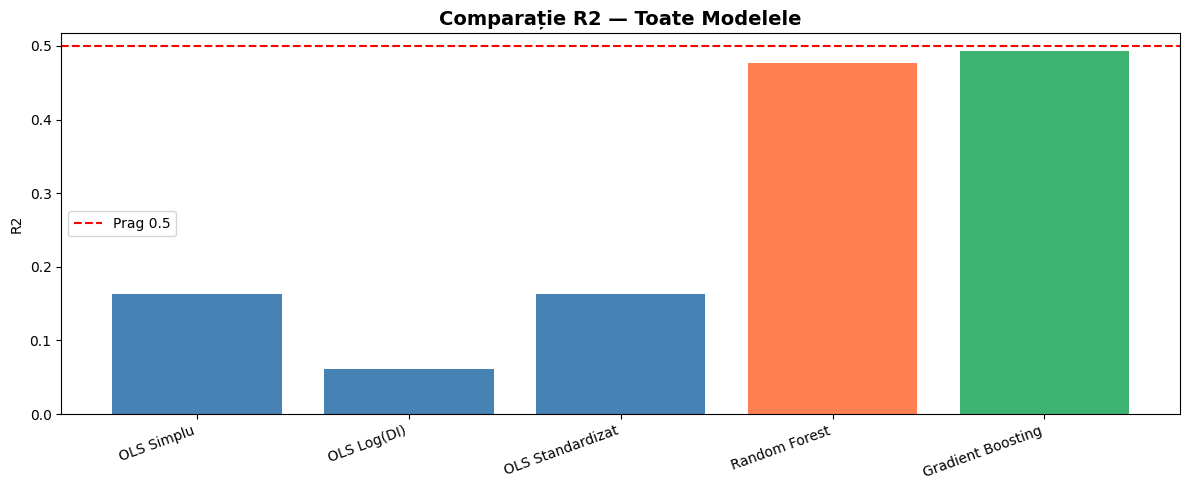

In [14]:
# Tabel comparație toate modelele
results = pd.DataFrame({
    'Model': [
        'OLS Simplu',
        'OLS Log(DI)',
        'OLS Standardizat',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2': [
        r2_ols,
        r2_log,
        r2_scaled,
        r2_rf,
        r2_gb
    ],
    'RMSE': [
        rmse_ols,
        rmse_log,
        rmse_scaled,
        rmse_rf,
        rmse_gb
    ]
})

print("Comparație finală — toate modelele:")
print(results.sort_values('R2', ascending=False).to_string(index=False))

# Grafic comparație R2
plt.figure(figsize=(12, 5))

colors = ['steelblue', 'steelblue', 'steelblue', 'coral', 'mediumseagreen']

plt.bar(results['Model'], results['R2'], color=colors)

plt.title('Comparație R2 — Toate Modelele', fontsize=14, fontweight='bold')
plt.ylabel('R2')
plt.xticks(rotation=20, ha='right')
plt.axhline(y=0.5, color='red', linestyle='--', label='Prag 0.5')
plt.legend()
plt.tight_layout()

plt.savefig('../data/comparatie_modele.png', dpi=150)
plt.show()

### Interpretare Comparatie Finala

**Clasamentul modelelor:**
- Gradient Boosting: R2 = 0.494 — locul 1
- Random Forest: R2 = 0.477 — locul 2
- OLS Simplu si Standardizat: R2 = 0.163 — locul 3
- OLS Log: R2 = 0.061 — locul 4
